# Imports

In [14]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


## Get data

In [15]:
def mean_std_over_seeds(curves_by_seed):
    """
    curves_by_seed: dict {seed: array of shape (n_train_sizes,)}
    """
    Y = np.stack(list(curves_by_seed.values()), axis=0)
    return Y.mean(axis=0), Y.std(axis=0)


In [16]:
# train_mse[seed] : shape (n_train_sizes, n_lambdas)
# test_mse[seed]  : shape (n_train_sizes, n_lambdas)


In [17]:
def load_best_lambda_curves(pkl_path, best_lambda):
    with open(pkl_path, "rb") as f:
        obj = pickle.load(f)

    train_sizes = obj["train_sizes"]
    lambdas = np.array(obj["lambdas"])
    li = np.where(lambdas == best_lambda)[0][0]

    train_curves = {s: obj["results"][s]["train_mse"][:, li] for s in obj["seeds"]}
    test_curves  = {s: obj["results"][s]["test_mse"][:, li]  for s in obj["seeds"]}

    train_mean, train_std = mean_std_over_seeds(train_curves)
    test_mean,  test_std  = mean_std_over_seeds(test_curves)

    gap_mean = test_mean - train_mean
    gap_std  = np.sqrt(train_std**2 + test_std**2)

    return {
        "train_sizes": train_sizes,
        "train_mean": train_mean,
        "train_std": train_std,
        "test_mean": test_mean,
        "test_std": test_std,
        "gap_mean": gap_mean,
        "gap_std": gap_std,
    }


In [18]:
def load_best_gaussian_curves(pkl_path, best_sigma_label, best_lambda):
    with open(pkl_path, "rb") as f:
        obj = pickle.load(f)

    train_sizes = obj["train_sizes"]
    lambdas = np.array(obj["lambdas"])
    li = np.where(lambdas == best_lambda)[0][0]

    train_curves = {}
    test_curves  = {}

    for seed in obj["seeds"]:
        entry = obj["results"][seed][best_sigma_label]
        train_curves[seed] = entry["train_mse"][:, li]
        test_curves[seed]  = entry["test_mse"][:, li]

    train_mean, train_std = mean_std_over_seeds(train_curves)
    test_mean,  test_std  = mean_std_over_seeds(test_curves)

    gap_mean = test_mean - train_mean
    gap_std  = np.sqrt(train_std**2 + test_std**2)

    return {
        "train_sizes": train_sizes,
        "train_mean": train_mean,
        "train_std": train_std,
        "test_mean": test_mean,
        "test_std": test_std,
        "gap_mean": gap_mean,
        "gap_std": gap_std,
    }


# Transverse Ising Hamiltonian

## Extrapolaton

In [19]:

method_ood = {
    r"Train Data: [$-4\pi$, $4\pi$]": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit3stepZ0Y14pi.pkl", 1e-15
    ),
    r"Train Data: [0, $4\pi$]": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit3stepZ0Y1extrapolate4pi.pkl", 1e-15
    ),
    r"Train Data: [$-2\pi$, $2\pi$]": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit3stepZ0Y1extrapolatem2pi2pi.pkl", 1e-15
    ),
    r"Train Data: [$0$, $2\pi$]": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit3stepZ0Y1extrapolate2pi.pkl", 1e-15
    ),
    r"Train Data: [$-\pi$, $\pi$]": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit3stepZ0Y1extrapolate.pkl", 1e-15
    ),

   
}

### Test Error

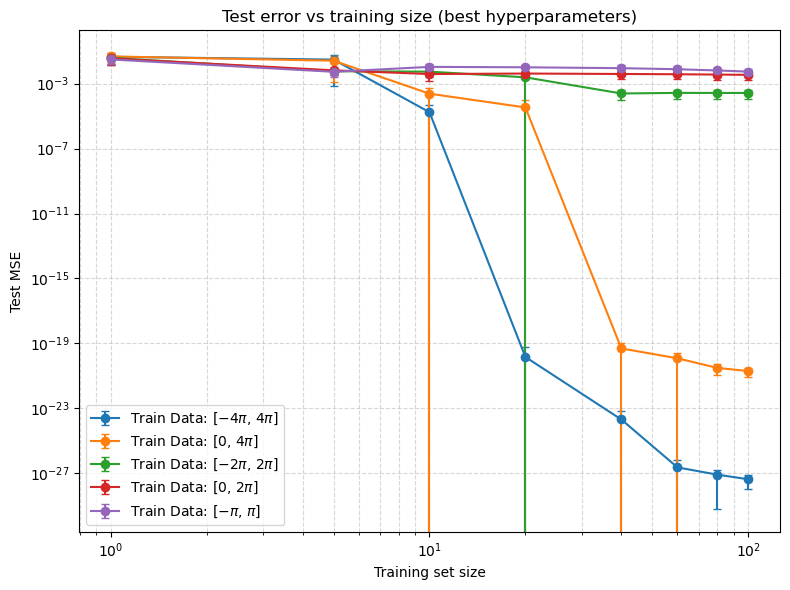

In [20]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [21]:
for name, res in method_ood.items():
    print(res["test_std"])

[3.04737721e-02 2.95461535e-02 2.81450410e-05 4.28073616e-20
 4.68797983e-24 4.04203017e-27 8.27219238e-28 3.25758913e-28]
[2.73865819e-02 2.46064905e-02 2.80974893e-04 6.71133876e-05
 6.14641944e-20 1.40429811e-20 2.02478058e-21 1.10396660e-21]
[0.02148678 0.00221213 0.00279765 0.00246702 0.00015355 0.00015454
 0.00015222 0.00015247]
[0.02152784 0.0032009  0.00234107 0.00215091 0.00200282 0.00192035
 0.00182891 0.00176014]
[0.01501458 0.00262435 0.00526946 0.00487395 0.00442172 0.00387232
 0.00312645 0.00269276]


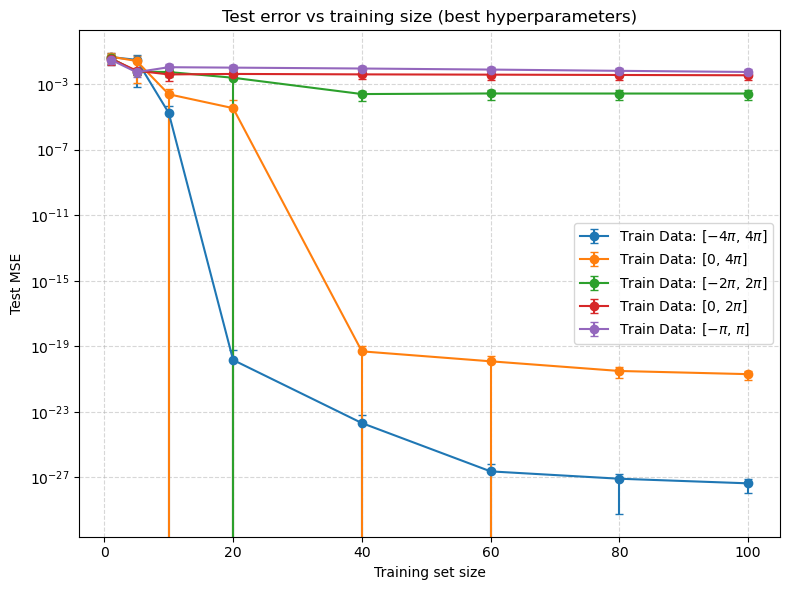

In [22]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


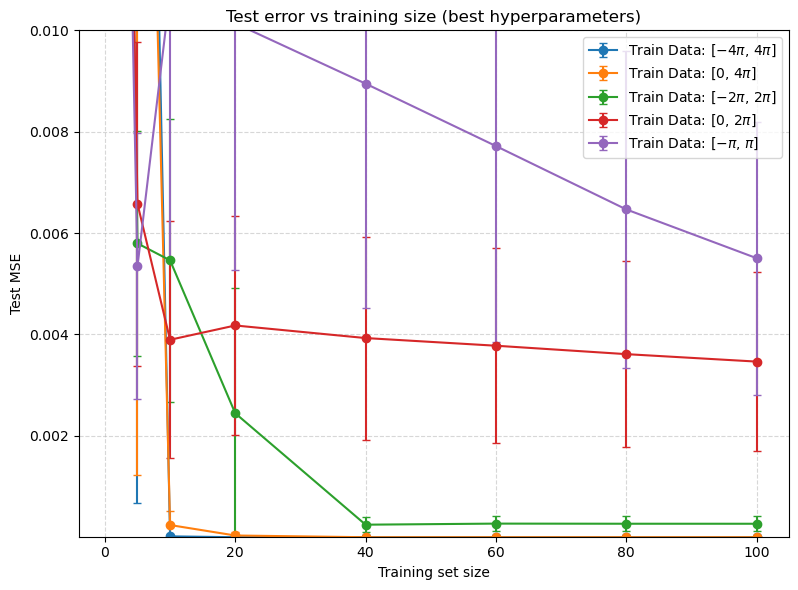

In [29]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.ylim(1e-5,1e-2)
plt.show()


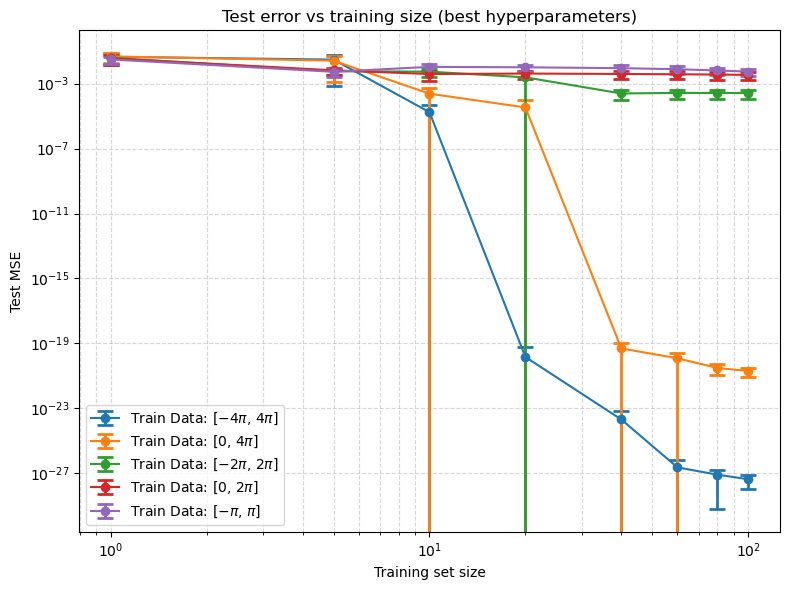

In [24]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=6,
        elinewidth=2,
        capthick=2,
        label=name
    )


plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


### Generalization Gap

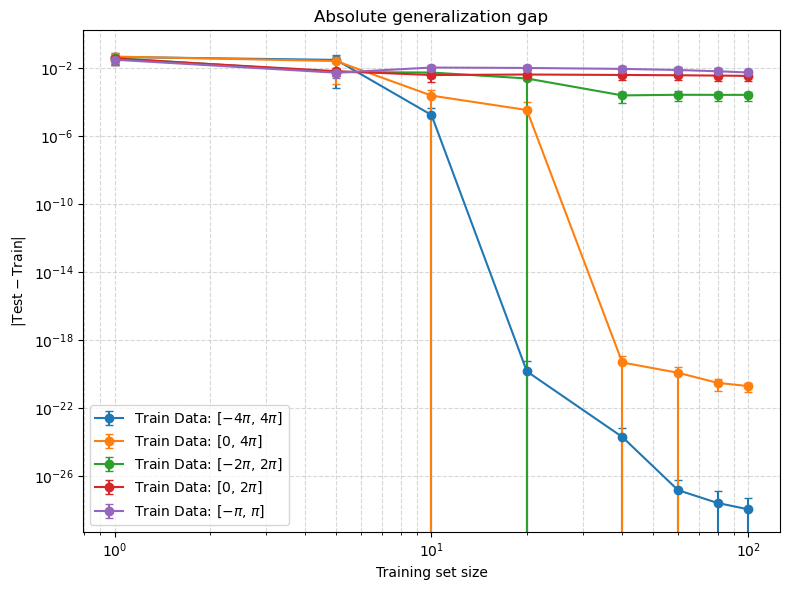

In [25]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

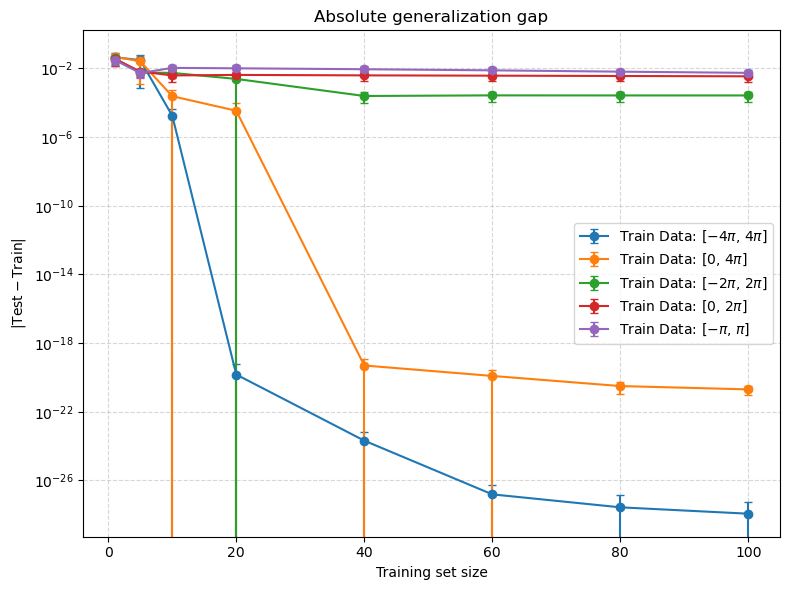

In [26]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
# plt.ylim(1e-40,1e-30)
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Different Observables

In [19]:

method_ood = {

    "ZZ": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit3step4pi.pkl", 1e-15
    ),
    "ZY": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit3stepZ0Y14pi.pkl", 1e-15
    ),
    "YY": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit3stepY0Y14pi.pkl", 1e-15
    ),
    "XY": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit3stepX0Y14pi.pkl", 1e-15
    ),

   
}

### Test Error

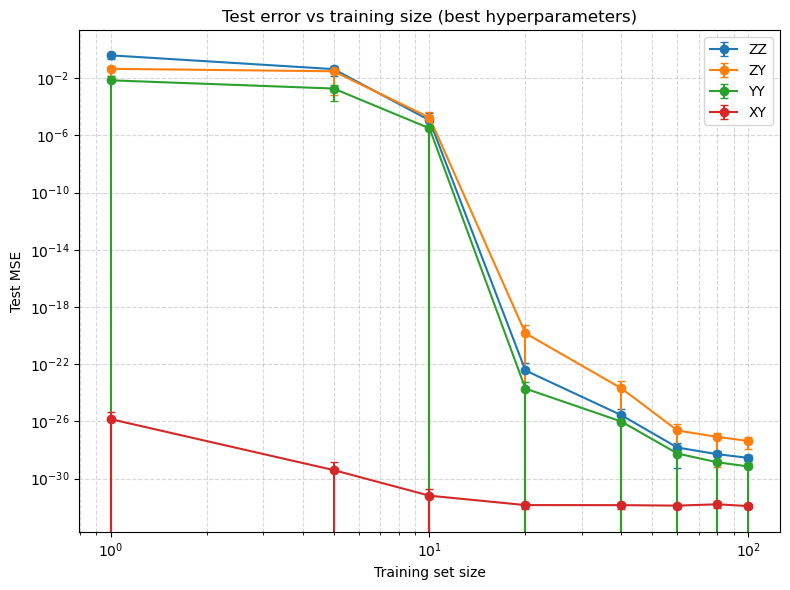

In [20]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [21]:
for name, res in method_ood.items():
    print(res["test_std"])

[1.67588679e-01 2.79443804e-02 2.37264783e-05 8.58067586e-23
 5.23022176e-26 1.44546878e-28 4.00115652e-29 1.53476666e-29]
[3.04737721e-02 2.95461535e-02 2.81450410e-05 4.28073616e-20
 4.68797983e-24 4.04203017e-27 8.27219238e-28 3.25758913e-28]
[7.35901583e-03 1.63728485e-03 8.95153635e-06 4.15721491e-24
 2.02112354e-26 9.26470618e-29 2.23046524e-29 9.86861068e-30]
[2.92331961e-26 1.14098241e-29 1.35415668e-31 7.04763196e-33
 6.61749293e-33 4.36065393e-33 7.72298376e-33 3.62029213e-33]


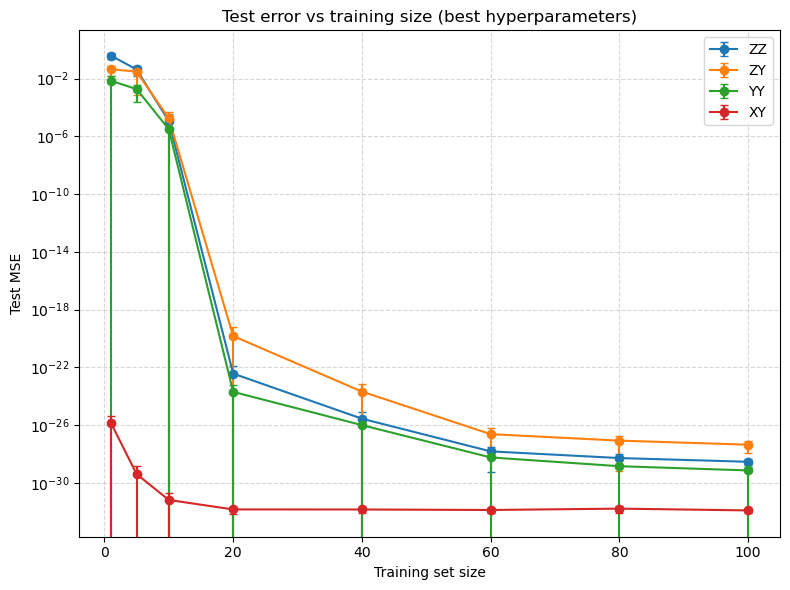

In [22]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


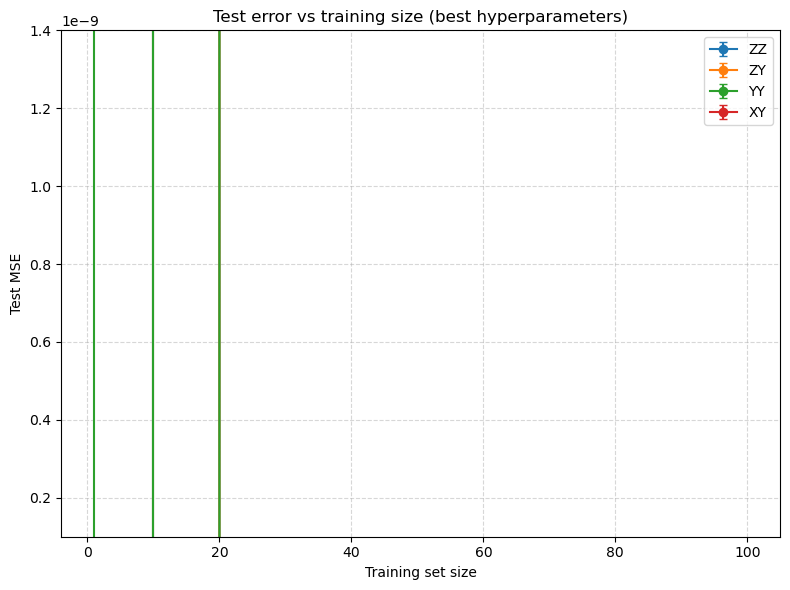

In [23]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.ylim(1e-10,1.4e-9)
plt.show()


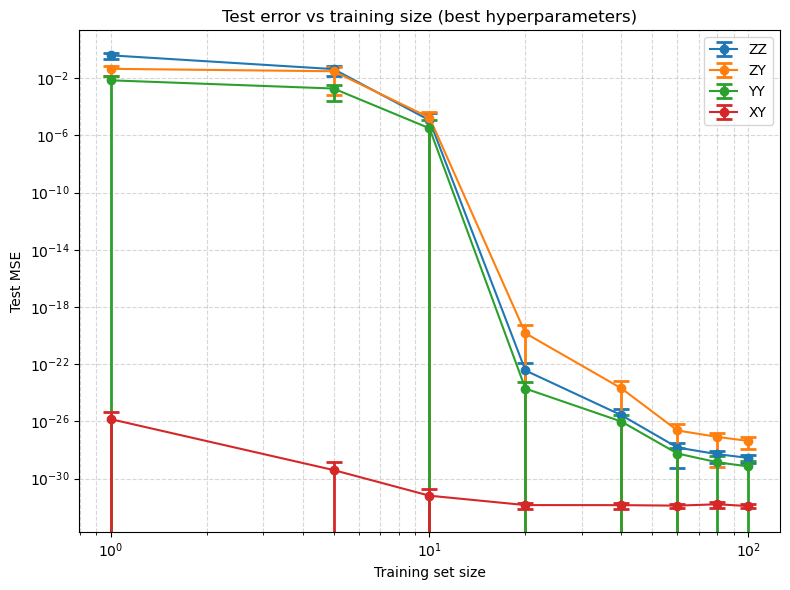

In [24]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=6,
        elinewidth=2,
        capthick=2,
        label=name
    )


plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


### Generalization Gap

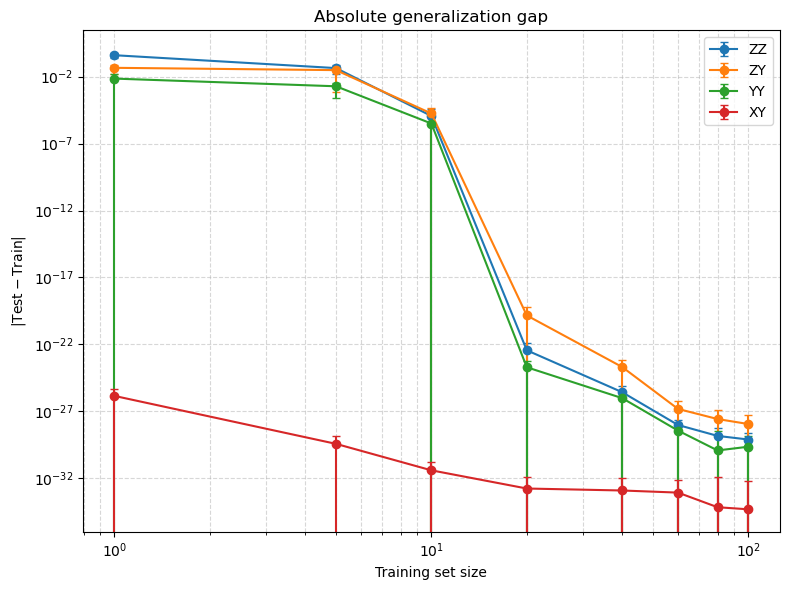

In [25]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

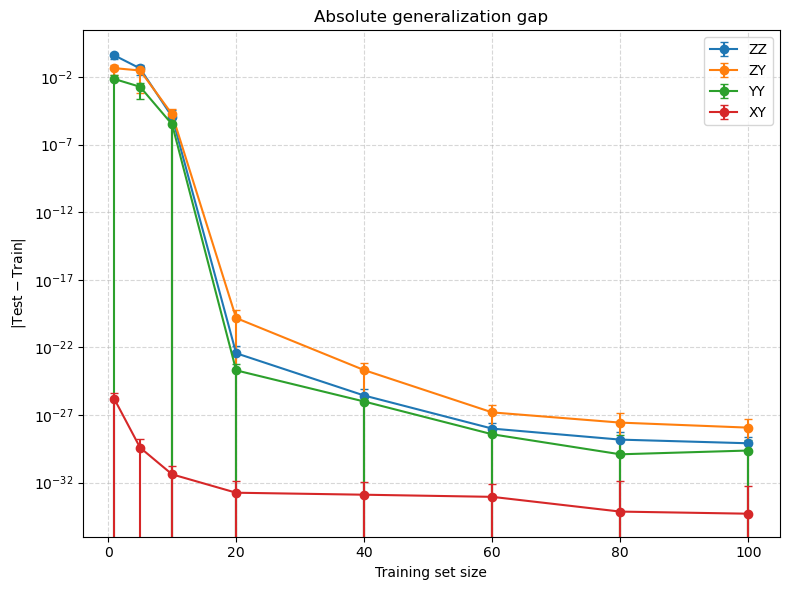

In [26]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
# plt.ylim(1e-40,1e-30)
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Varying Trotter Steps

In [6]:

method_ood = {

    "2 Qubits 1 step": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit1stepnobound.pkl", 1e-15
    ),
    "2 Qubits 2 step": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit2step.pkl", 1e-15
    ),
    "2 Qubits 3 step": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit3step.pkl", 1e-15
    ),
    "2 Qubits 4 step": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit4step.pkl", 1e-15
    ),
    "2 Qubits 5 step": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit5step.pkl", 1e-15
    ),
   
}

### Test Error

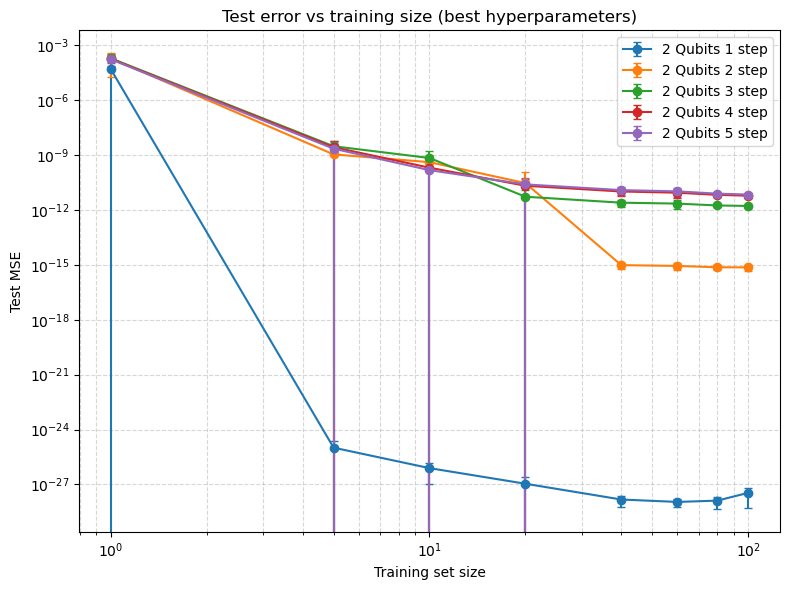

In [7]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [8]:
for name, res in method_ood.items():
    print(res["test_std"])

[5.34743772e-05 1.21088134e-25 6.69084993e-27 1.54948680e-27
 8.78376833e-29 5.22324414e-29 8.69413216e-29 2.96703966e-28]
[1.73829565e-04 1.07674496e-09 5.57323129e-10 8.69742767e-11
 3.51624024e-16 3.54231888e-16 2.38567574e-16 2.61727373e-16]
[1.44672622e-04 3.14422338e-09 9.71303642e-10 7.29297800e-12
 1.02338169e-12 1.05924873e-12 3.81311659e-13 3.24855597e-13]
[1.17759127e-04 3.13345048e-09 4.18691458e-10 2.72002060e-11
 4.23401025e-12 4.14041152e-12 1.50881422e-12 1.28117589e-12]
[9.92420238e-05 2.74500341e-09 3.06813405e-10 3.17207031e-11
 5.13883692e-12 4.97034809e-12 1.79734896e-12 1.50473231e-12]


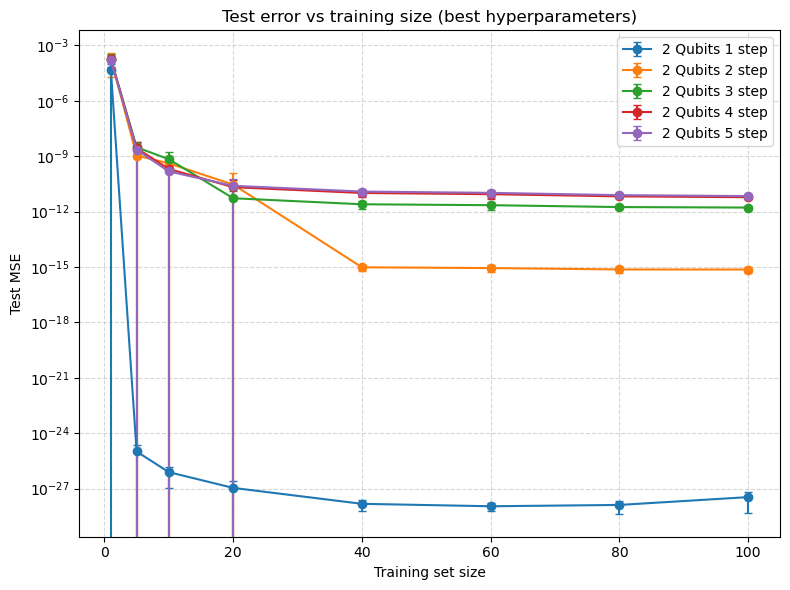

In [9]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


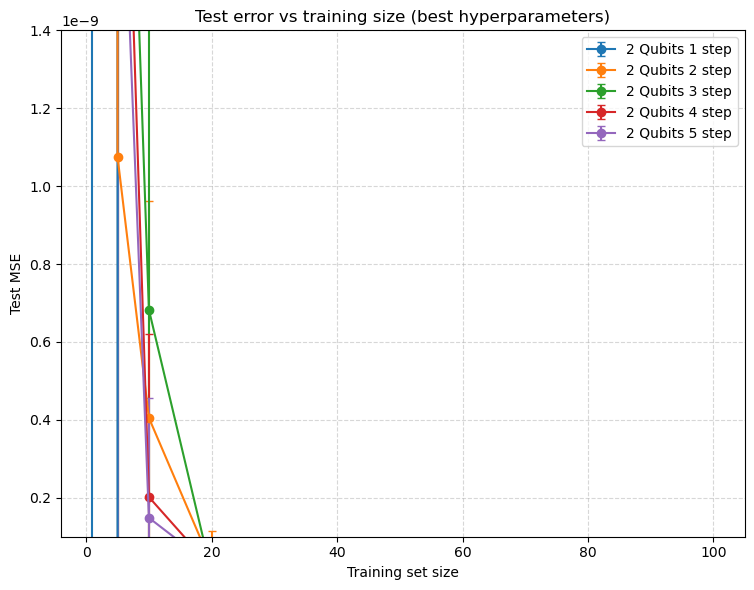

In [10]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.ylim(1e-10,1.4e-9)
plt.show()


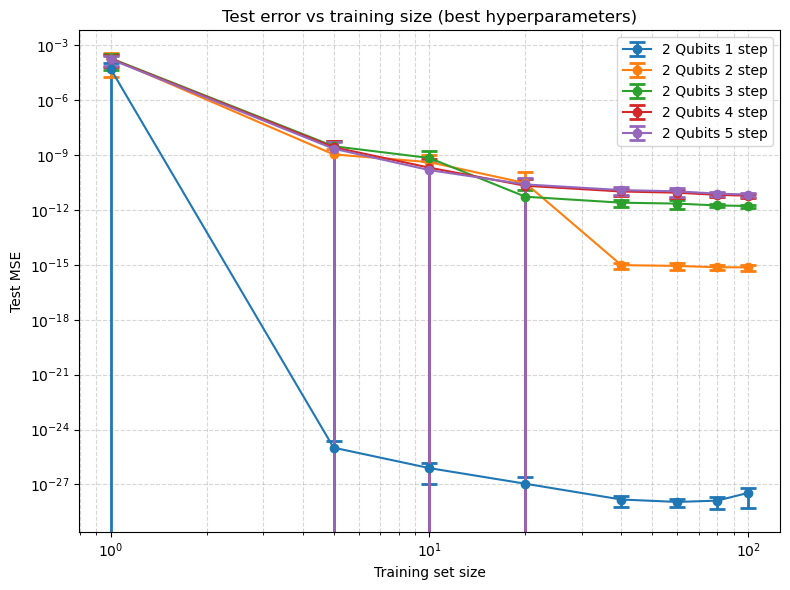

In [11]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=6,
        elinewidth=2,
        capthick=2,
        label=name
    )


plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


### Generalization Gap

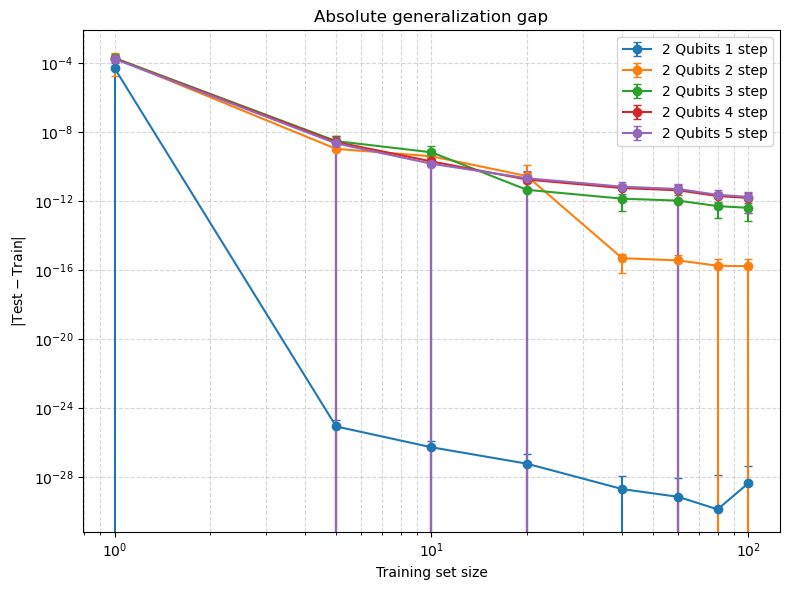

In [12]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

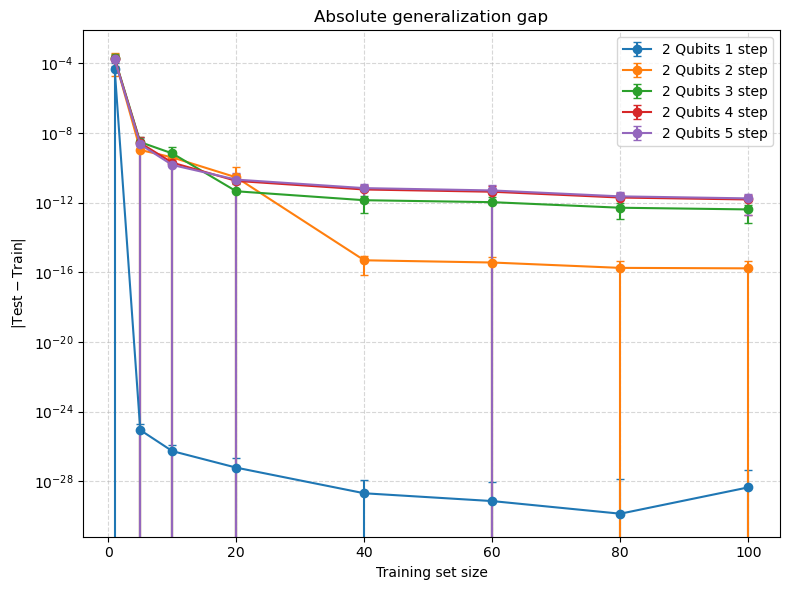

In [13]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
# plt.ylim(1e-40,1e-30)
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Comparing different Qubits

In [43]:

method_ood = {

    "2 Qubits 1 step no bound": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit1stepnobound.pkl", 1e-15
    ),
    "2 Qubits 2 step no bound": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit2step.pkl", 1e-11
    ),
    "2 Qubits 3 step no bound": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit3step.pkl", 1e-11
    ),
    "2 Qubits 4 step no bound": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit4step.pkl", 1e-11
    ),
    "2 Qubits 5 step no bound": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit5step.pkl", 1e-11
    ),
    "3 Qubits 1 step no bound": load_best_lambda_curves(
        "results/mse_results_TIHP_threequbit1step.pkl", 1e-15
    )

   
}

### Test Error

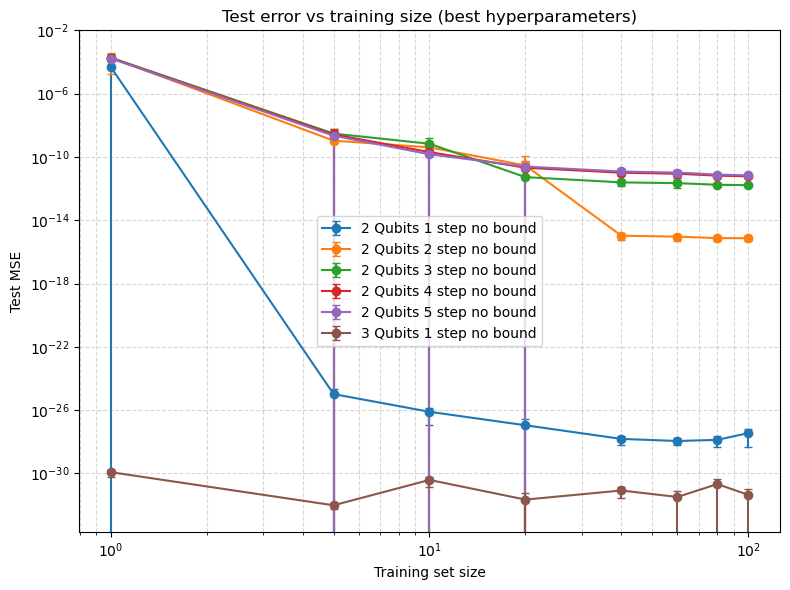

In [44]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [45]:
for name, res in method_ood.items():
    print(res["test_std"])

[5.34743772e-05 1.21088134e-25 6.69084993e-27 1.54948680e-27
 8.78376833e-29 5.22324414e-29 8.69413216e-29 2.96703966e-28]
[1.73829565e-04 1.07684110e-09 5.57715480e-10 8.72342930e-11
 4.62082168e-16 4.42999650e-16 2.52313102e-16 2.74098565e-16]
[1.44672622e-04 3.14462579e-09 9.72712413e-10 7.47757243e-12
 1.02833432e-12 1.06422503e-12 3.81955120e-13 3.24831824e-13]
[1.17759127e-04 3.13392538e-09 4.19138546e-10 2.73848449e-11
 4.23861958e-12 4.14585224e-12 1.50969550e-12 1.28133709e-12]
[9.92420240e-05 2.74543013e-09 3.07225684e-10 3.18751504e-11
 5.14272232e-12 4.97510978e-12 1.79824593e-12 1.50499080e-12]
[5.54135241e-31 4.23634548e-33 2.40644477e-31 3.25370688e-32
 5.50724913e-32 4.04415206e-32 2.11076524e-31 6.19225743e-32]


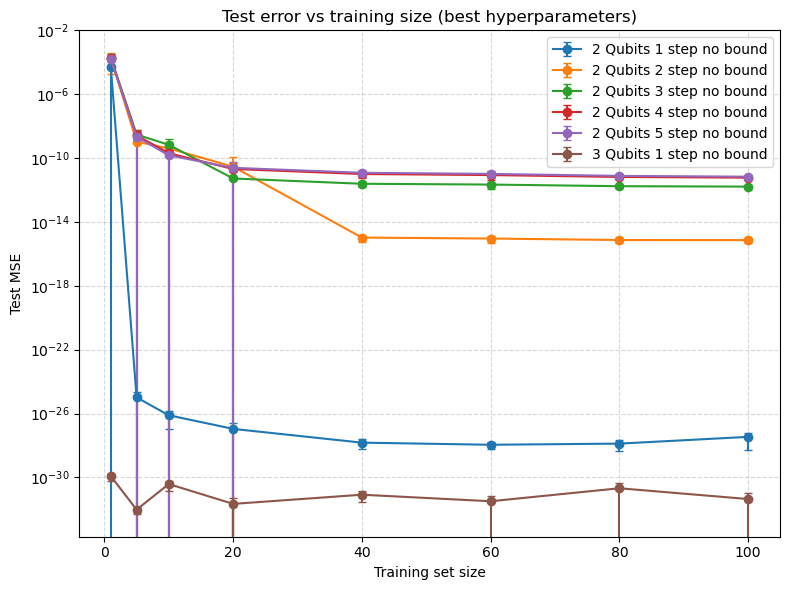

In [46]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


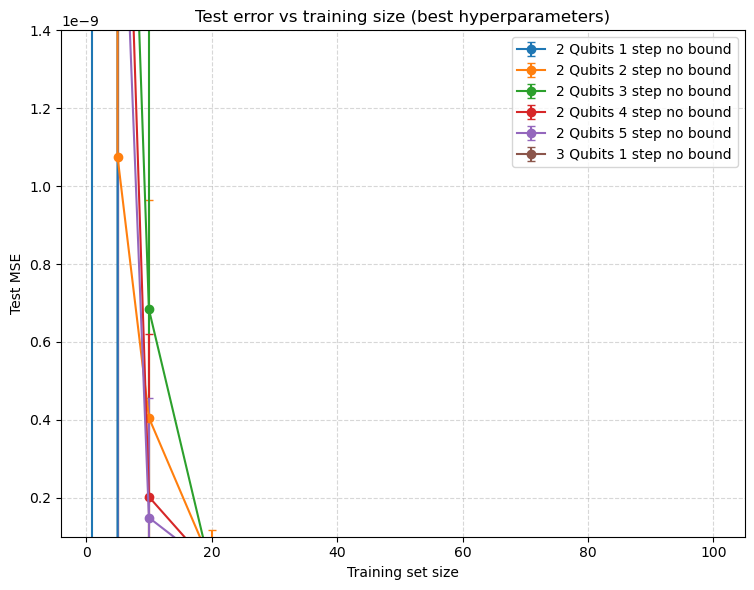

In [47]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.ylim(1e-10,1.4e-9)
plt.show()


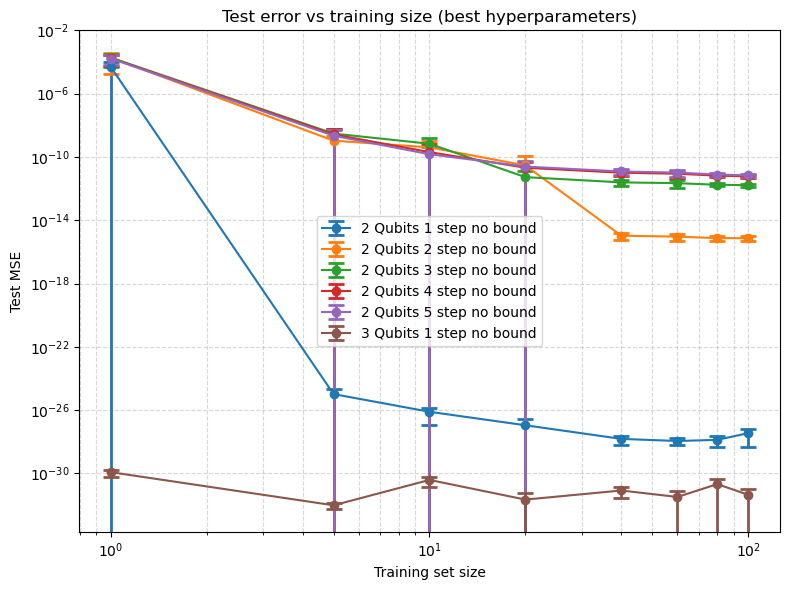

In [48]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=6,
        elinewidth=2,
        capthick=2,
        label=name
    )


plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


### Generalization Gap

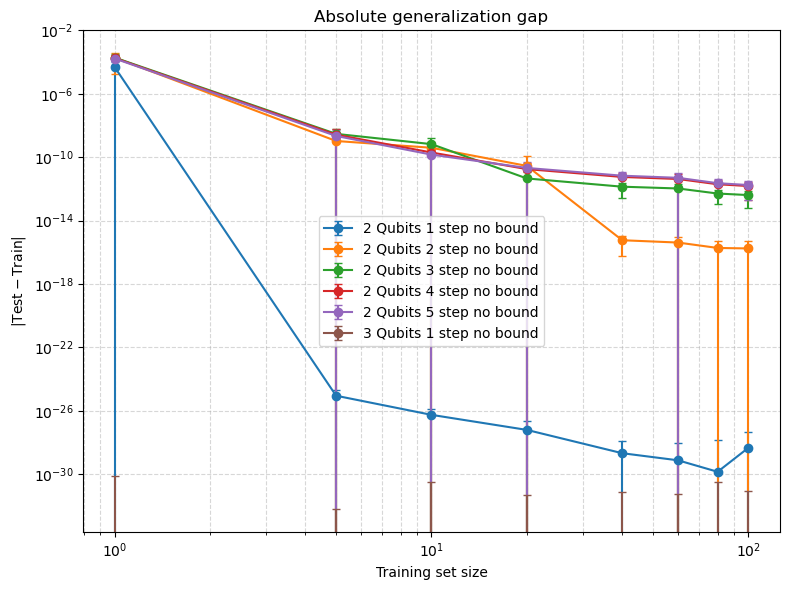

In [49]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

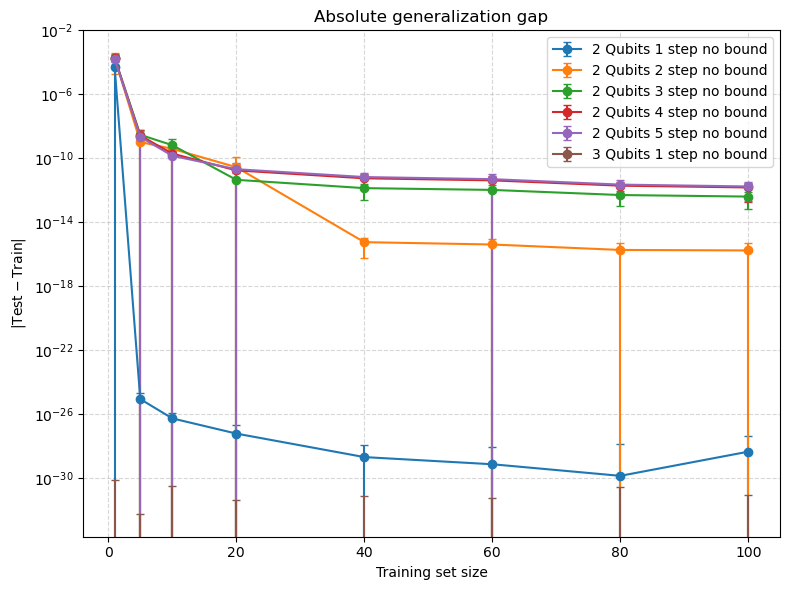

In [50]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
# plt.ylim(1e-40,1e-30)
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Comparing different methods(2 Qubits 1 step $\lambda = $ 1e-3 )

In [51]:

method_ood = {
    "2 Qubits 1 step no bound": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit1stepnobound.pkl", 0.001
    ),
    "2 Qubits 1 step bounded warm start": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit1step.pkl", 0.001
    ),
    "2 Qubits 1 step bounded no warm start": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit1stepnowarm.pkl", 0.001
    ),
    "2 Qubits 1 step bounded bad warm start": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit1stepbadwarm.pkl", 0.001
    ),

   
}

### Test Error

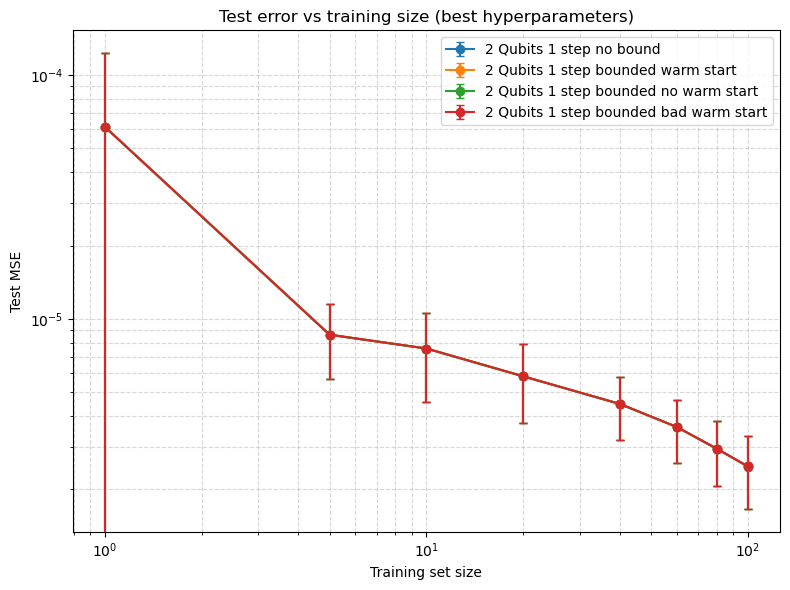

In [52]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [53]:
for name, res in method_ood.items():
    print(res["test_std"])

[6.16602777e-05 2.93179774e-06 3.00827438e-06 2.06339224e-06
 1.29398336e-06 1.04121373e-06 8.76068528e-07 8.24092505e-07]
[6.16602777e-05 2.93552905e-06 3.00831036e-06 2.06339225e-06
 1.29398340e-06 1.04121373e-06 8.77026688e-07 8.25784439e-07]
[6.16602777e-05 2.93552905e-06 3.00831035e-06 2.06339226e-06
 1.29398333e-06 1.04121381e-06 8.77017146e-07 8.25794425e-07]
[6.16602777e-05 2.93552905e-06 3.00831035e-06 2.06339226e-06
 1.29398333e-06 1.04121381e-06 8.77017146e-07 8.25794425e-07]


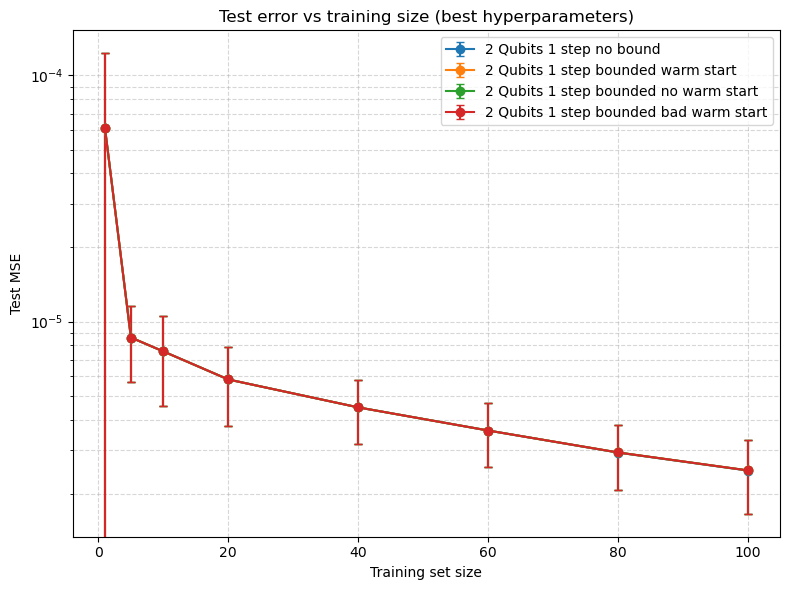

In [54]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


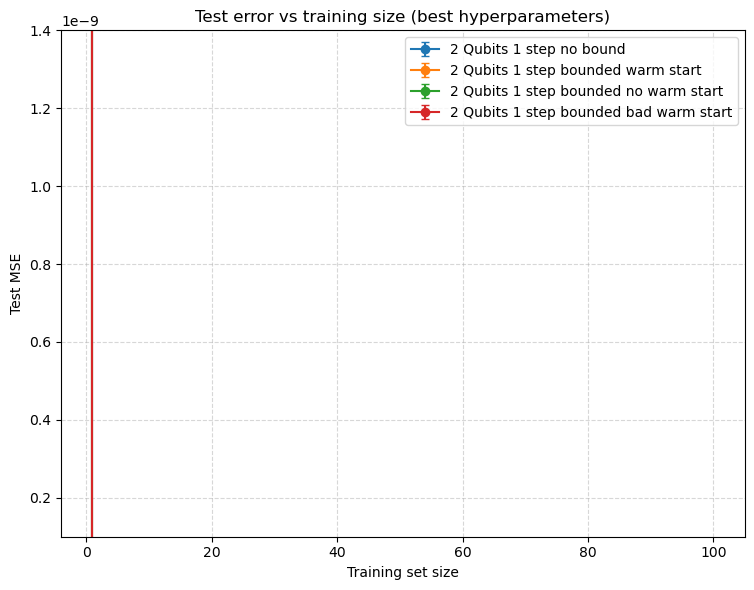

In [55]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.ylim(1e-10,1.4e-9)
plt.show()


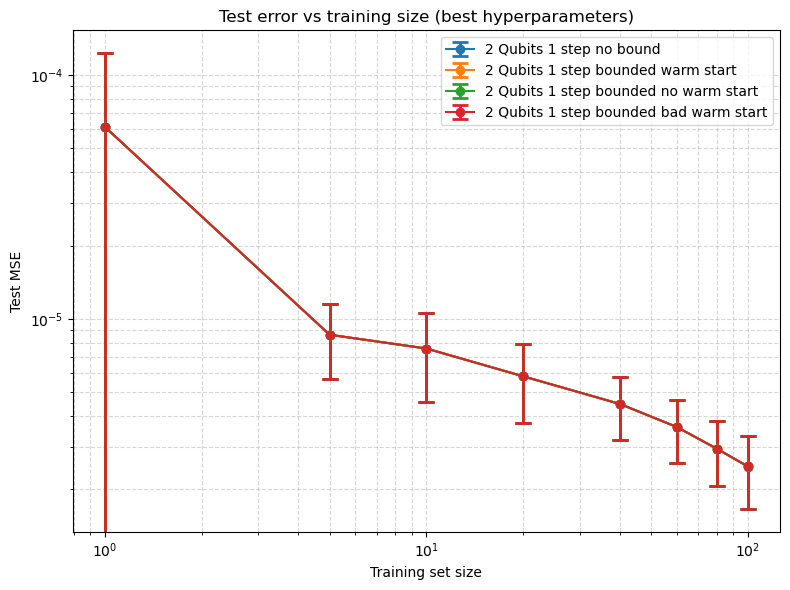

In [56]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=6,
        elinewidth=2,
        capthick=2,
        label=name
    )


plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


### Generalization Gap

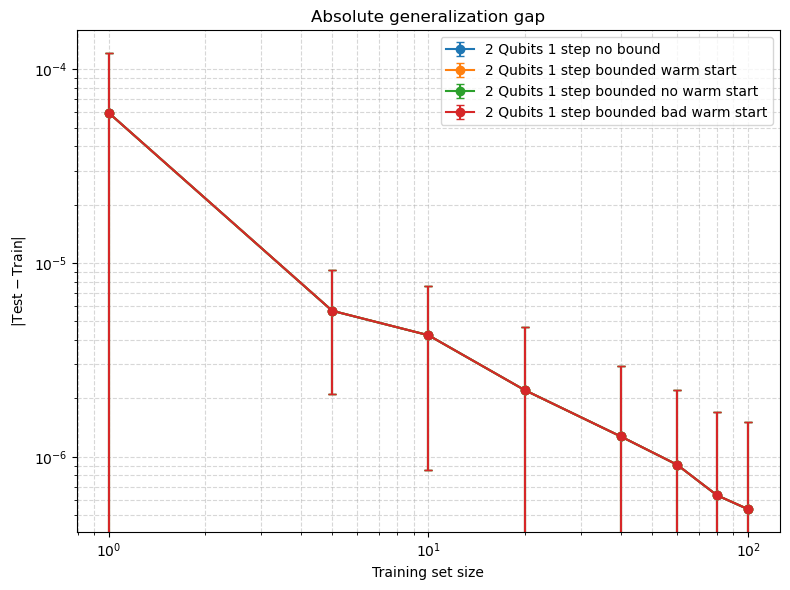

In [57]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

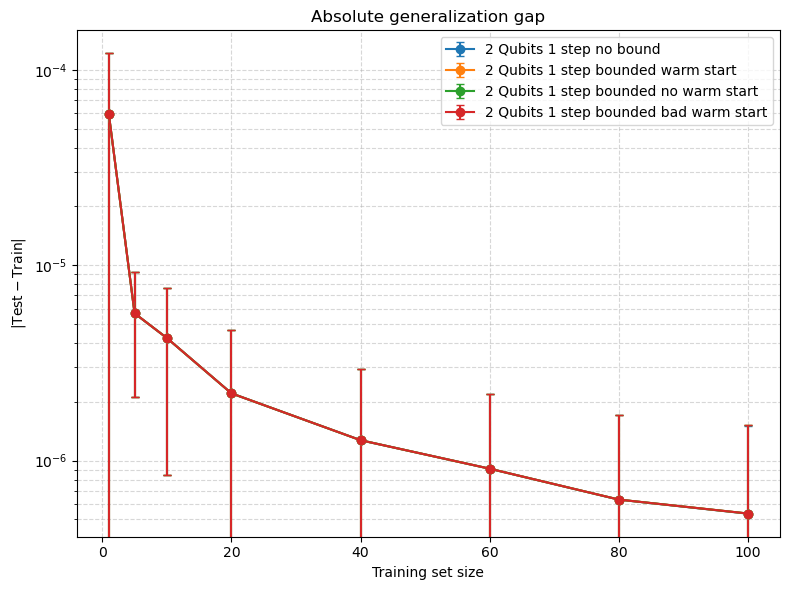

In [58]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Comparing different methods(2 Qubits 1 step $\lambda = $ 1e-15)

In [59]:

method_ood = {
    "2 Qubits 1 step no bound": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit1stepnobound.pkl", 1e-15
    ),
    "2 Qubits 1 step bounded warm start": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit1step.pkl", 1e-15
    ),
    "2 Qubits 1 step bounded no warm start": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit1stepnowarm.pkl", 1e-15
    ),
    "2 Qubits 1 step bounded bad warm start": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit1stepbadwarm.pkl", 1e-15
    ),

   
}

### Test Error

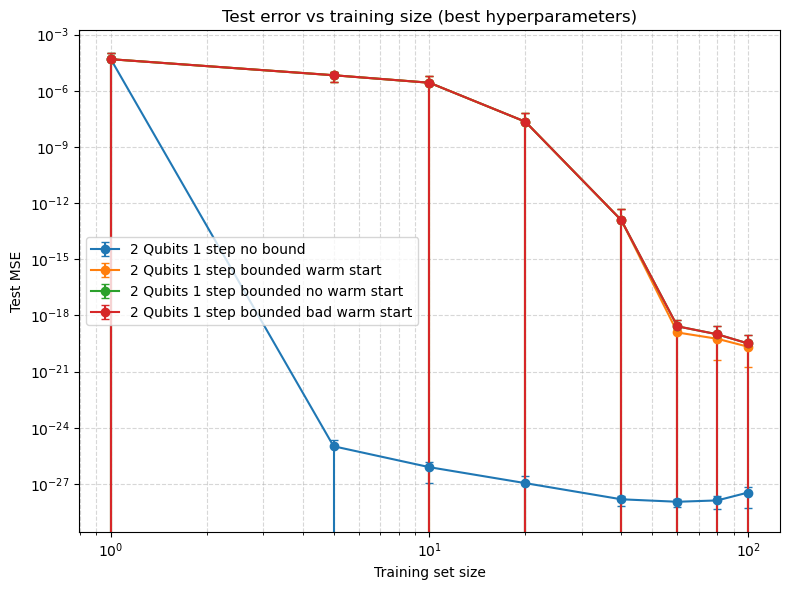

In [60]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [61]:
for name, res in method_ood.items():
    print(res["test_std"])

[5.34743772e-05 1.21088134e-25 6.69084993e-27 1.54948680e-27
 8.78376833e-29 5.22324414e-29 8.69413216e-29 2.96703966e-28]
[5.34743772e-05 3.62813324e-06 3.37108296e-06 4.17592752e-08
 3.62579520e-13 2.03413171e-19 5.24430363e-20 1.92699119e-20]
[5.34743772e-05 3.62813325e-06 3.37108306e-06 4.17593225e-08
 3.62503237e-13 3.33090942e-19 1.60338094e-19 5.39982619e-20]
[5.34743772e-05 3.62813325e-06 3.37108306e-06 4.17593225e-08
 3.62503237e-13 3.33090942e-19 1.60338094e-19 5.39982619e-20]


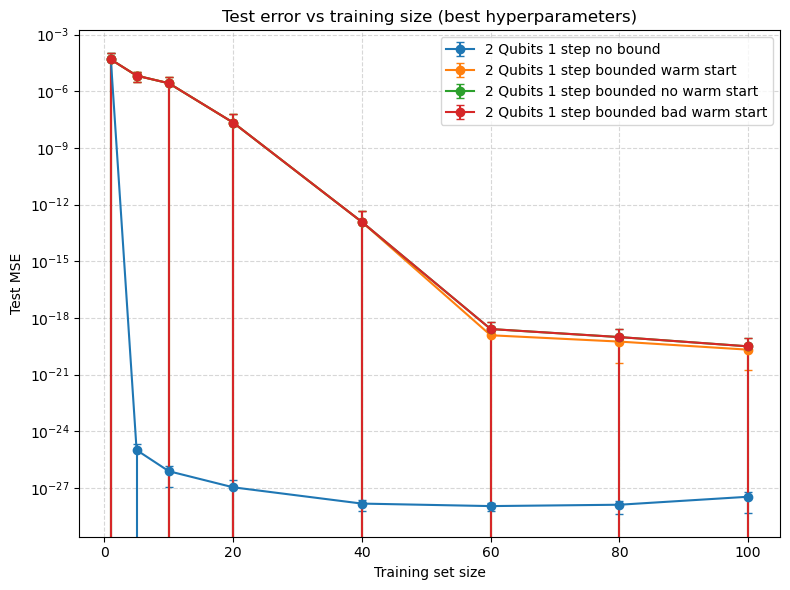

In [62]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


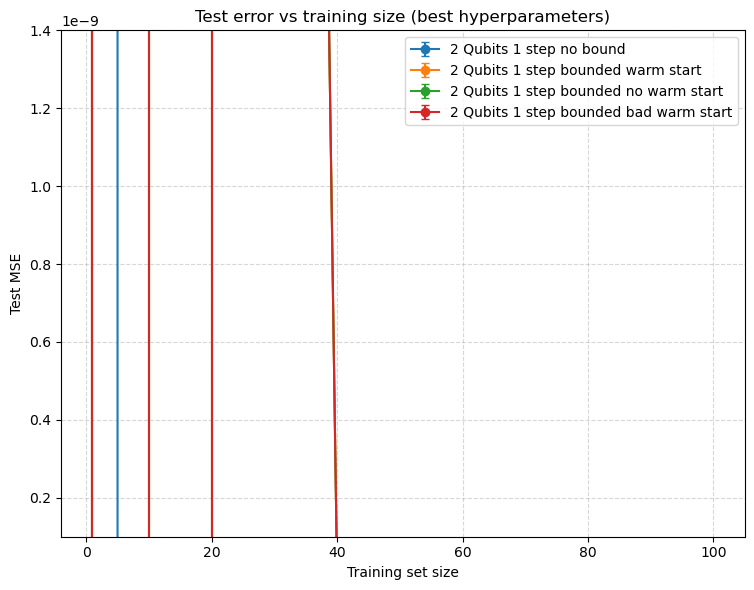

In [63]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.ylim(1e-10,1.4e-9)
plt.show()


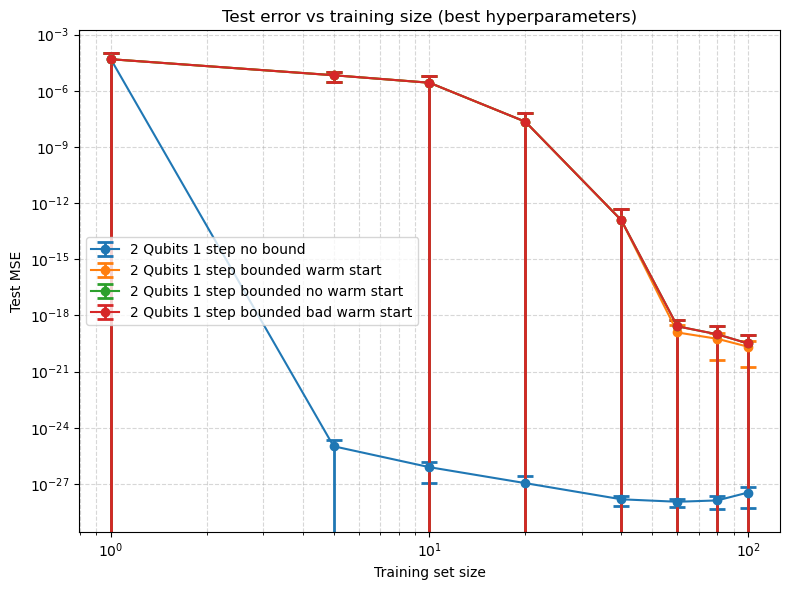

In [64]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=6,
        elinewidth=2,
        capthick=2,
        label=name
    )


plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


### Generalization Gap

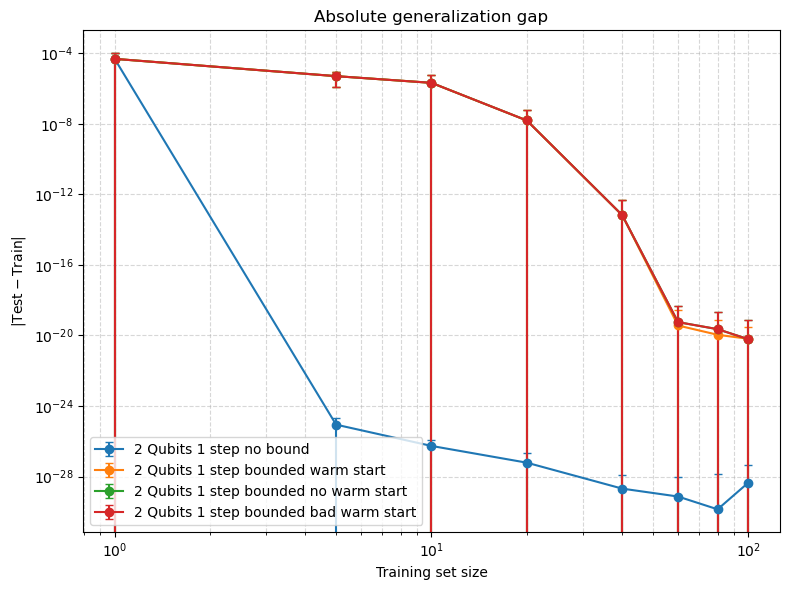

In [65]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

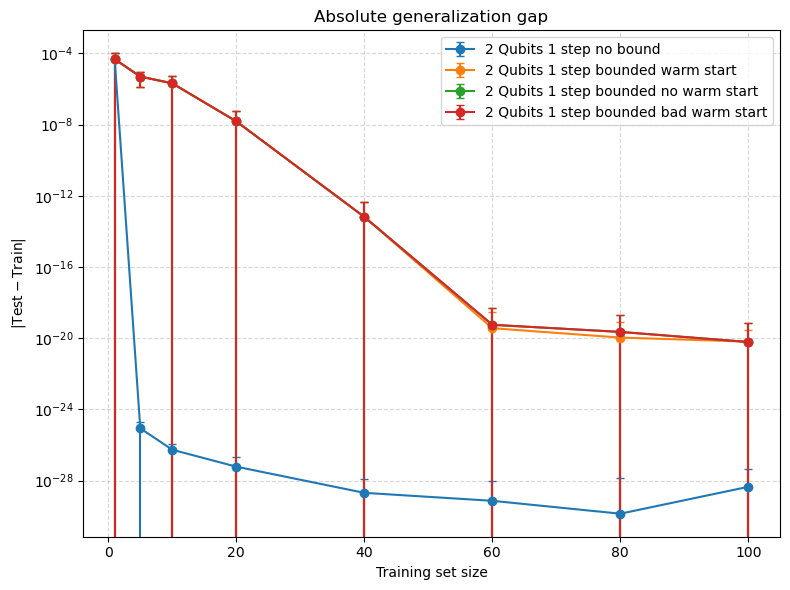

In [66]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Comparing different methods(3 Qubits 1 step $\lambda = $ 1e-3)

In [67]:

method_ood = {
    "3 Qubits 1 step no bound": load_best_lambda_curves(
        "results/mse_results_TIHP_threequbit1stepnobound.pkl", 0.001
    ),
    "3 Qubits 1 step bounded warm start": load_best_lambda_curves(
        "results/mse_results_TIHP_threequbit1step.pkl", 0.001
    ),
    "3 Qubits 1 step bounded no warm start": load_best_lambda_curves(
        "results/mse_results_TIHP_threequbit1stepnowarm.pkl", 0.001
    ),
    "3 Qubits 1 step bounded bad warm start": load_best_lambda_curves(
        "results/mse_results_TIHP_threequbit1stepbadwarm.pkl", 0.001
    ),
   
}

### Test Error

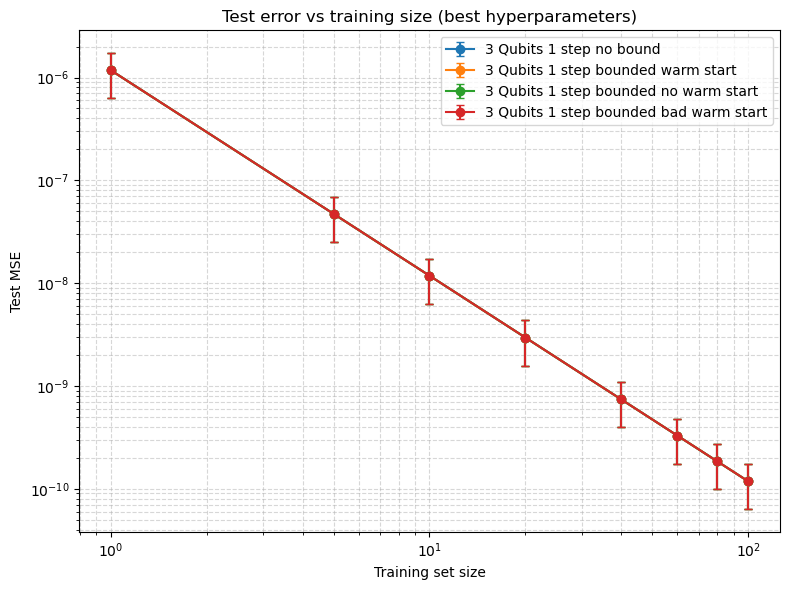

In [68]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [69]:
for name, res in method_ood.items():
    print(res["test_std"])

[5.49241728e-07 2.20400001e-08 5.51220381e-09 1.37832655e-09
 3.44616095e-10 1.53167814e-10 8.61583313e-11 5.51418834e-11]
[5.49241728e-07 2.20400001e-08 5.51220381e-09 1.37832655e-09
 3.44616095e-10 1.53167814e-10 8.61583313e-11 5.51418834e-11]
[5.49241728e-07 2.20400001e-08 5.51220381e-09 1.37832655e-09
 3.44616095e-10 1.53167814e-10 8.61583313e-11 5.51418834e-11]
[5.49241728e-07 2.20400001e-08 5.51220381e-09 1.37832655e-09
 3.44616095e-10 1.53167814e-10 8.61583313e-11 5.51418834e-11]


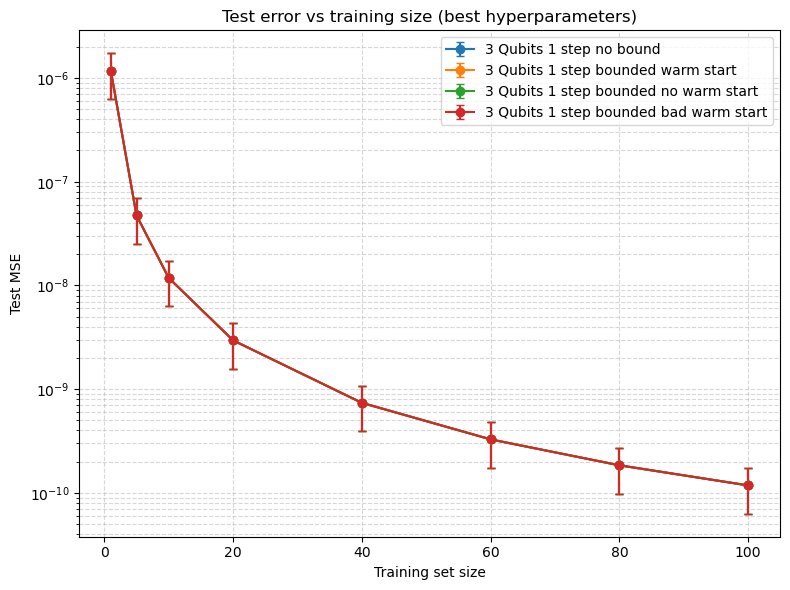

In [70]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


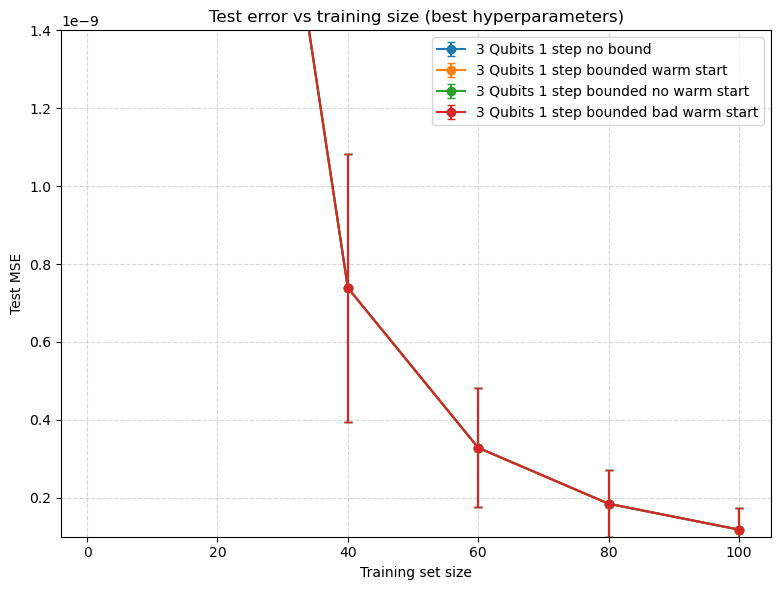

In [71]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.ylim(1e-10,1.4e-9)
plt.show()


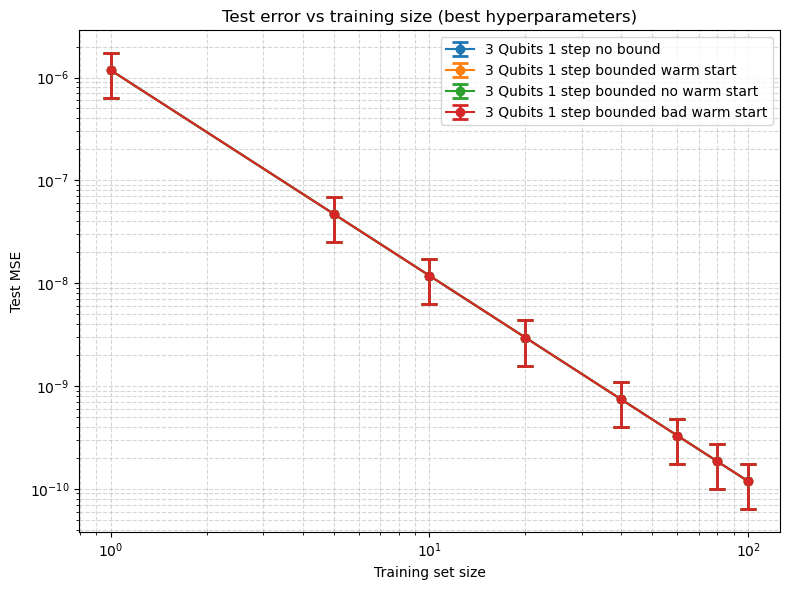

In [72]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=6,
        elinewidth=2,
        capthick=2,
        label=name
    )


plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


### Generalization Gap

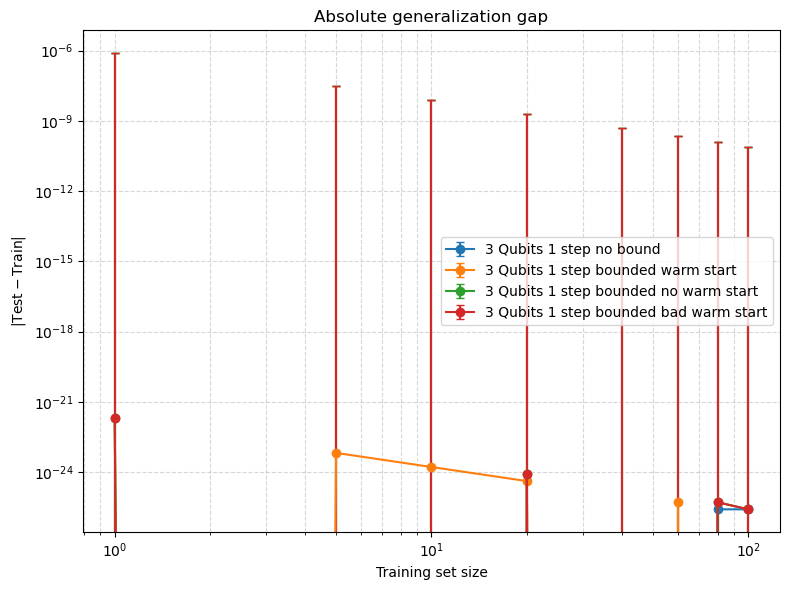

In [73]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

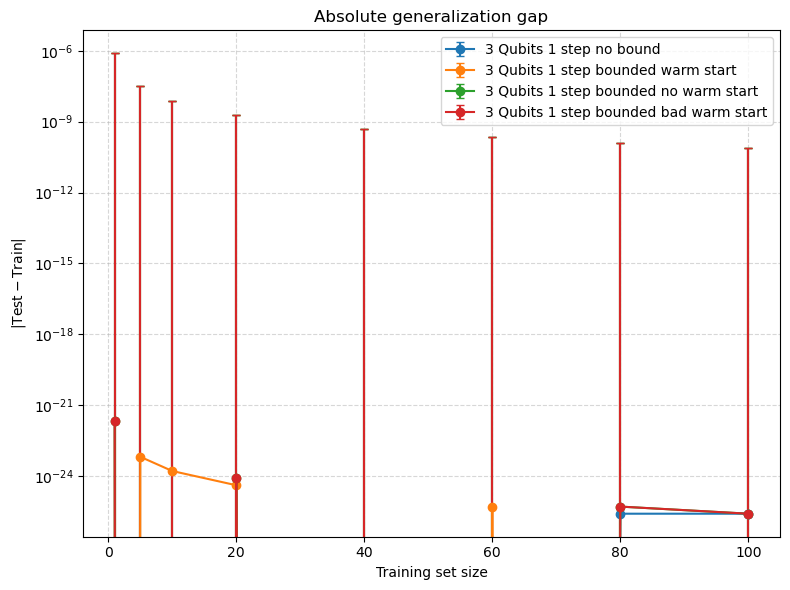

In [74]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()